<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/%5BProject_1%5D_The_cost_of_stepping_back_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ========================================================================================================================
# ECON3916 | Project 1 Current Phase 2: Data Audit & EDA
# Student: Aahan Desai
# Dataset: Mroz (1987) Female Labor Supply
# Research Q: Cost of Stepping Back(Human Capital Depreciation) vs Household Facilitation(Added Worker Effect)
# ========================================================================================================================

In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [ ]:
#data_ingestion
url = "https://pages.stern.nyu.edu/~wgreene/Text/Edition7/TableF5-1.csv"
df = pd.read_csv(url)
df.head()

,LFP,WHRS,KL6,K618,WA,WE,WW,RPWG,HHRS,HA,HE,HW,FAMINC,MTR,WMED,WFED,UN,CIT,AX
0,1,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310,0.7215,12,7,5.0,0,14
1,1,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800,0.6615,7,7,11.0,1,5
2,1,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040,0.6915,12,7,5.0,0,15
3,1,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300,0.7815,7,7,5.0,0,6
4,1,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300,0.6215,12,14,9.5,1,7


In [ ]:
#rename
df = df.rename(columns={
    'LFP':    'works',
    'WHRS':   'hours',
    'KL6':    'kids_young',
    'K618':   'kids_old',
    'WA':     'age',
    'WE':     'educ',
    'WW':     'wage',
    'RPWG':   'wage_reported',
    'HHRS':   'husb_hours',
    'HA':     'husb_age',
    'HE':     'husb_educ',
    'HW':     'husb_wage',
    'FAMINC': 'fam_inc',
    'MTR':    'tax_rate',
    'WMED':   'moth_educ',
    'WFED':   'fath_educ',
    'UN':     'unemp_rate',
    'CIT':    'city',
    'AX ':    'exp'
})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   works          753 non-null    int64  
 1   hours          753 non-null    int64  
 2   kids_young     753 non-null    int64  
 3   kids_old       753 non-null    int64  
 4   age            753 non-null    int64  
 5   educ           753 non-null    int64  
 6   wage           753 non-null    float64
 7   wage_reported  753 non-null    float64
 8   husb_hours     753 non-null    int64  
 9   husb_age       753 non-null    int64  
 10  husb_educ      753 non-null    int64  
 11  husb_wage      753 non-null    float64
 12  fam_inc        753 non-null    int64  
 13  tax_rate       753 non-null    float64
 14  moth_educ      753 non-null    int64  
 15  fath_educ      753 non-null    int64  
 16  unemp_rate     753 non-null    float64
 17  city           753 non-null    int64  
 18  exp       

In [ ]:
df.describe()

,works,hours,kids_young,kids_old,age,educ,wage,wage_reported,husb_hours,husb_age,husb_educ,husb_wage,fam_inc,tax_rate,moth_educ,fath_educ,unemp_rate,city,exp
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.00000
mean,0.568393,740.576361,0.237716,1.353254,42.537849,12.286853,2.374565,1.849734,2267.270916,45.120850,12.491368,7.482179,23080.594954,0.678863,9.250996,8.808765,8.623506,0.642762,10.63081
std,0.495630,871.314216,0.523959,1.319874,8.072574,2.280246,3.241829,2.419887,595.566649,8.058793,3.020804,4.230559,12190.202026,0.083496,3.367468,3.572290,3.114934,0.479504,8.06913
min,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,0.000000,175.000000,30.000000,3.000000,0.412100,1500.000000,0.441500,0.000000,0.000000,3.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,36.000000,12.000000,0.000000,0.000000,1928.000000,38.000000,11.000000,4.788300,15428.000000,0.621500,7.000000,7.000000,7.500000,0.000000,4.00000
50%,1.000000,288.000000,0.000000,1.000000,43.000000,12.000000,1.625000,0.000000,2164.000000,46.000000,12.000000,6.975800,20880.000000,0.691500,10.000000,7.000000,7.500000,1.000000,9.00000
75%,1.000000,1516.000000,0.000000,2.000000,49.000000,13.000000,3.787900,3.580000,2553.000000,52.000000,15.000000,9.166700,28200.000000,0.721500,12.000000,12.000000,11.000000,1.000000,15.00000
max,1.000000,4950.000000,3.000000,8.000000,60.000000,17.000000,25.000000,9.980000,5010.000000,60.000000,17.000000,40.509000,96000.000000,0.941500,17.000000,17.000000,14.000000,1.000000,45.00000


works            0
hours            0
kids_young       0
kids_old         0
age              0
educ             0
wage             0
wage_reported    0
husb_hours       0
husb_age         0
husb_educ        0
husb_wage        0
fam_inc          0
tax_rate         0
moth_educ        0
fath_educ        0
unemp_rate       0
city             0
exp              0
dtype: int64


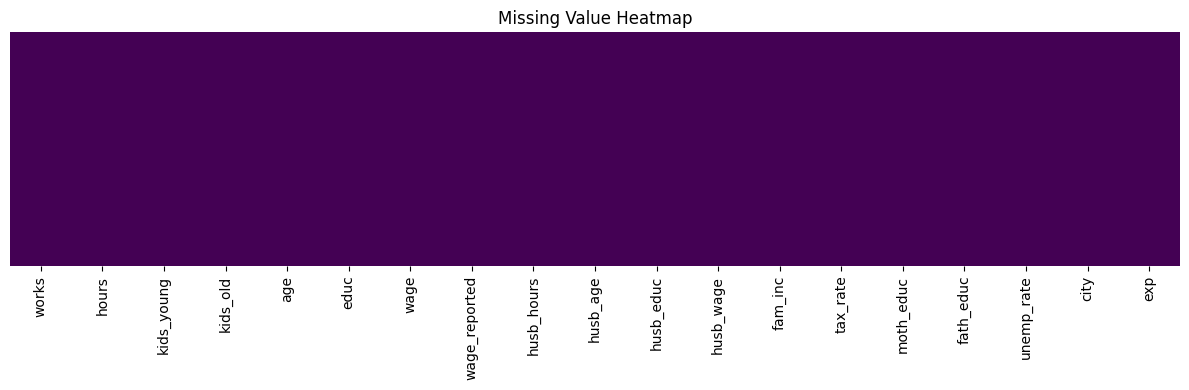

In [ ]:
#missing_val_vis
print(df.isnull().sum())
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()

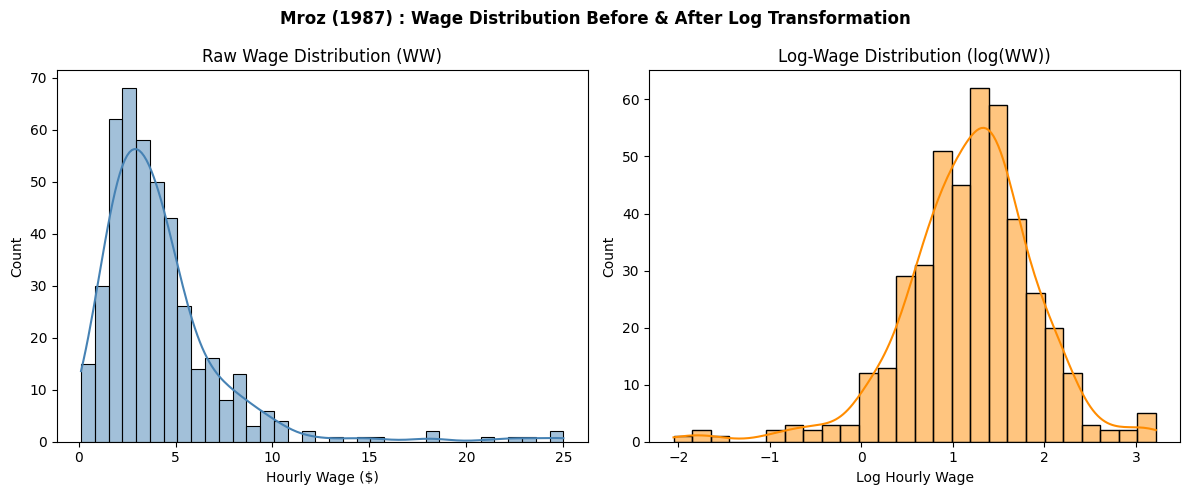

In [ ]:
#log_normalization_viz
workers = df[df['works'] == 1].copy()
workers['log_wage'] = np.log(workers['wage'])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(workers['wage'], kde=True, color='steelblue')
plt.title("Raw Wage Distribution (WW)")
plt.xlabel("Hourly Wage ($)")
plt.subplot(1, 2, 2)
sns.histplot(workers['log_wage'], kde=True, color='darkorange')
plt.title("Log-Wage Distribution (log(WW))")
plt.xlabel("Log Hourly Wage")
plt.suptitle("Mroz (1987) : Wage Distribution Before & After Log Transformation",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_894/4050694875.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=workers, x='kids_young', y='log_wage',


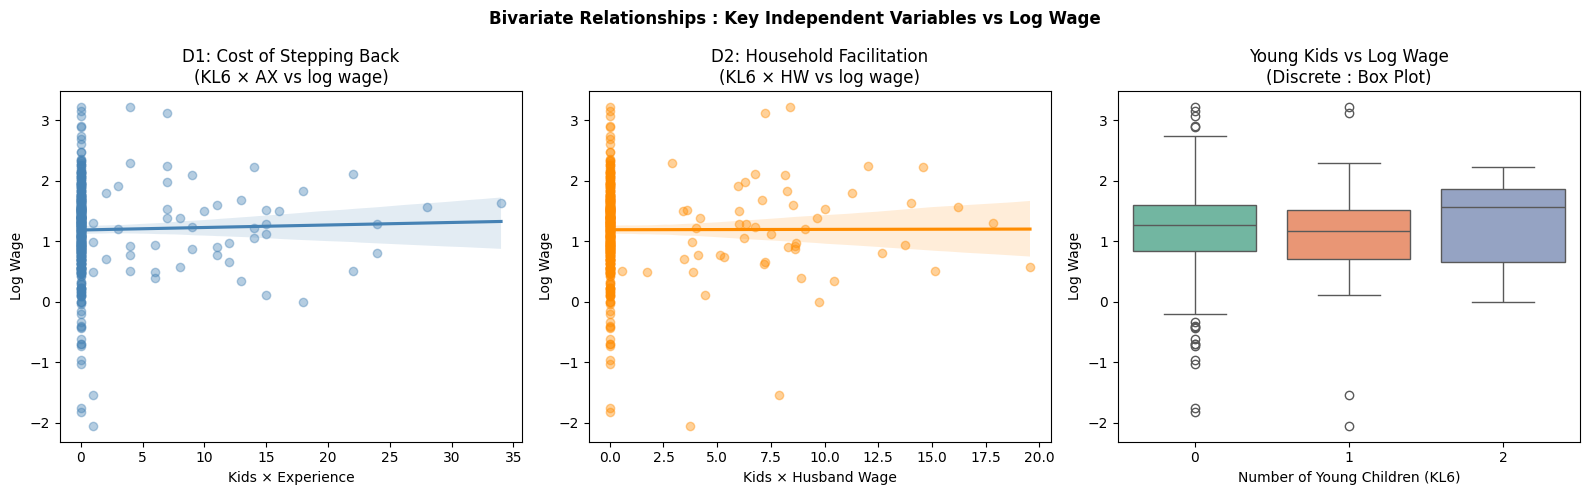

In [ ]:
#Bivariate relationship plotted (Scatter & Box)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
#D1:KL6 × AX (Kids young X Experience)
workers['kl6_x_ax'] = workers['kids_young'] * workers['exp']
sns.regplot(data=workers, x='kl6_x_ax', y='log_wage',
            ax = axes[0], scatter_kws={'alpha':0.4}, color='steelblue')
axes[0].set_title("D1: Cost of Stepping Back\n(KL6 × AX vs log wage)")
axes[0].set_xlabel("Kids × Experience")
axes[0].set_ylabel("Log Wage")
#D2:KL6 × HW (Kids young X Husband wages)
workers['kl6_x_hw'] = workers['kids_young'] * workers['husb_wage']
sns.regplot(data=workers, x='kl6_x_hw', y='log_wage',
            ax=axes[1], scatter_kws={'alpha':0.4}, color='darkorange')
axes[1].set_title("D2: Household Facilitation\n(KL6 × HW vs log wage)")
axes[1].set_xlabel("Kids × Husband Wage")
axes[1].set_ylabel("Log Wage")
#KL6 vs Log(wage) [Box plot]
sns.boxplot(data=workers, x='kids_young', y='log_wage',
            ax=axes[2], palette='Set2')
axes[2].set_title("Young Kids vs Log Wage\n(Discrete : Box Plot)")
axes[2].set_xlabel("Number of Young Children (KL6)")
axes[2].set_ylabel("Log Wage")
plt.suptitle("Bivariate Relationships : Key Independent Variables vs Log Wage",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#tukey fence outlier detection
for var in ['log_wage', 'exp', 'husb_wage', 'kl6_x_ax', 'kl6_x_hw']:
    Q1  = workers[var].quantile(0.25)
    Q3  = workers[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = workers[(workers[var] < lower) | (workers[var] > upper)].shape[0]
    pct   = n_out / len(workers) * 100
    print(f"{var:<15} | Outliers: {n_out} ({pct:.1f}%) | Fence: [{lower:.2f}, {upper:.2f}]")

log_wage        | Outliers: 20 (4.7%) | Fence: [-0.36, 2.78]
exp             | Outliers: 7 (1.6%) | Fence: [-9.50, 34.50]
husb_wage       | Outliers: 16 (3.7%) | Fence: [-1.20, 14.86]
kl6_x_ax        | Outliers: 51 (11.9%) | Fence: [0.00, 0.00]
kl6_x_hw        | Outliers: 53 (12.4%) | Fence: [0.00, 0.00]


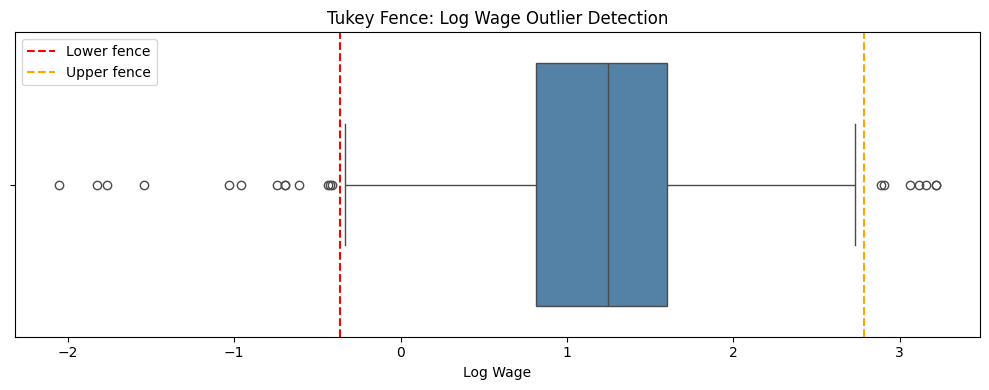

In [ ]:
#tukey_fence_viz
Q1  = workers['log_wage'].quantile(0.25)
Q3  = workers['log_wage'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plt.figure(figsize=(10, 4))
sns.boxplot(x=workers['log_wage'], color='steelblue')
plt.axvline(lower, color='red',    linestyle='--', label=f'Lower fence')
plt.axvline(upper, color='orange', linestyle='--', label=f'Upper fence')
plt.title("Tukey Fence: Log Wage Outlier Detection")
plt.xlabel("Log Wage")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#model 0
#baseline. No kids, just human capital
formula_0 = 'np.log(wage) ~ educ + exp + age'
model_0   = smf.ols(formula=formula_0, data=workers).fit(cov_type='HC1')
print("MODEL 0: BASELINE ")
print(model_0.summary())

MODEL 0: BASELINE 
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     26.80
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           6.86e-16
Time:                        18:23:33   Log-Likelihood:                -433.69
No. Observations:                 428   AIC:                             875.4
Df Residuals:                     424   BIC:                             891.6
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3469      0.274 

In [ ]:
#model 1
#Kids x experince effect on Log wage
formula_1 = 'np.log(wage) ~ kids_young + exp + kl6_x_ax + educ + age + kids_old'
model_1   = smf.ols(formula=formula_1, data=workers).fit(cov_type='HC1')
print("MODEL 1: COST OF STEPPING BACK (D1: KL6 × AX)")
print(model_1.summary())

MODEL 1: COST OF STEPPING BACK (D1: KL6 × AX)
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     13.68
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.28e-14
Time:                        18:27:07   Log-Likelihood:                -432.72
No. Observations:                 428   AIC:                             879.4
Df Residuals:                     421   BIC:                             907.9
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

In [ ]:
#model 2
#Kids x husband wage eff on log wage
formula_2 = 'np.log(wage) ~ kids_young + husb_wage + kl6_x_hw + educ + age + kids_old'
model_2   = smf.ols(formula=formula_2, data=workers).fit(cov_type='HC1')
print("MODEL 2: HOUSEHOLD FACILITATION (D2: KL6 × HW)")
print(model_2.summary())

MODEL 2: HOUSEHOLD FACILITATION (D2: KL6 × HW)
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     12.00
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.88e-12
Time:                        18:24:27   Log-Likelihood:                -437.05
No. Observations:                 428   AIC:                             888.1
Df Residuals:                     421   BIC:                             916.5
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

In [ ]:
#Main model/Model 3
#Horse race between model 1 and 2
formula_final = 'np.log(wage) ~ kids_young + exp + husb_wage + kl6_x_ax + kl6_x_hw + educ + age + kids_old'
model_final   = smf.ols(formula=formula_final, data=workers).fit(cov_type='HC1')
print("MODEL 3: HORSE RACE — BOTH MECHANISMS")
print(model_final.summary())

MODEL 3: HORSE RACE — BOTH MECHANISMS
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     11.35
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.34e-14
Time:                        19:27:47   Log-Likelihood:                -430.17
No. Observations:                 428   AIC:                             878.3
Df Residuals:                     419   BIC:                             914.9
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

## Coefficient Interpretation (Ceteris Paribus)

### Model 0: Baseline (Mincerian Wage Equation)

| Variable | Coefficient | Interpretation |
|----------|-------------|----------------|
| **educ** | 0.1093*** | Holding experience and age constant, a one-year increase in education is associated with approximately a **10.9% increase in hourly wages**. |
| **exp** | 0.0163*** | Holding education and age constant, a one-year increase in labor market experience is associated with approximately a **1.6% increase in hourly wages**. |
| **age** | −0.0014 | Holding education and experience constant, age has no statistically significant effect on wages (p = 0.797). |

---

### Model 1: Cost of Stepping Back (Human Capital Depreciation)

| Variable | Coefficient | Interpretation |
|----------|-------------|----------------|
| **educ** | 0.1098*** | Holding all other variables constant, a one-year increase in education is associated with approximately an **11.0% increase in hourly wages**. |
| **exp** | 0.0145*** | Holding all other variables constant, a one-year increase in experience is associated with approximately a **1.5% increase in hourly wages**. |
| **kids_young** | −0.2174 | Holding all other variables constant, having young children is associated with approximately 21.7% lower wages, but this effect is **not statistically significant** (p = 0.413). |
| **kl6_x_ax** | 0.0147 | Holding all other variables constant, the interaction between young children and experience is **not statistically significant** (p = 0.460). There is no evidence that young children depreciate the returns to labor market experience. |

---

### Model 2: Household Facilitation (Added Worker Effect)

| Variable | Coefficient | Interpretation |
|----------|-------------|----------------|
| **educ** | 0.1035*** | Holding all other variables constant, a one-year increase in education is associated with approximately a **10.4% increase in hourly wages**. |
| **husb_wage** | 0.0163 | Holding all other variables constant, a $1/hour increase in husband's wage is associated with approximately 1.6% higher wages, but this effect is **not statistically significant** (p = 0.113). |
| **kl6_x_hw** | −0.0260 | Holding all other variables constant, the interaction between young children and husband's wage is **not statistically significant** (p = 0.416). There is no evidence that higher husband earnings buffer the motherhood wage penalty. |

---

### Model 3: Horse Race (Both Mechanisms)

| Variable | Coefficient | Interpretation |
|----------|-------------|----------------|
| **educ** | 0.1014*** | Holding all other variables constant, a one-year increase in education is associated with approximately a **10.1% increase in hourly wages**. This effect is robust across all specifications. |
| **exp** | 0.0165*** | Holding all other variables constant, a one-year increase in experience is associated with approximately a **1.7% increase in hourly wages**. |
| **husb_wage** | 0.0226** | Holding all other variables constant, a $1/hour increase in husband's wage is associated with approximately a **2.3% increase in the wife's hourly wages** (p = 0.028). This likely reflects assortative mating rather than a causal household production mechanism. |
| **kids_young** | −0.0152 | Holding all other variables constant, the direct effect of young children on wages is essentially zero and **not statistically significant** (p = 0.968). |
| **kl6_x_ax** | 0.0130 | The human capital depreciation mechanism (D1) is **not supported**—the interaction is not statistically significant (p = 0.518). |
| **kl6_x_hw** | −0.0263 | The household facilitation mechanism (D2) is **not supported**—the interaction is not statistically significant (p = 0.402). |

---

In [ ]:
print("MODEL COMPARISON")
print(f"{'Model':<12} {'R²':>8} {'Adj R²':>8} {'AIC':>10}")
print(f"{'Baseline':<12} {model_0.rsquared:8.4f} {model_0.rsquared_adj:8.4f} {model_0.aic:10.2f}")
print(f"{'D1 Only':<12} {model_1.rsquared:8.4f} {model_1.rsquared_adj:8.4f} {model_1.aic:10.2f}")
print(f"{'D2 Only':<12} {model_2.rsquared:8.4f} {model_2.rsquared_adj:8.4f} {model_2.aic:10.2f}")
print(f"{'Horse Race':<12} {model_final.rsquared:8.4f} {model_final.rsquared_adj:8.4f} {model_final.aic:10.2f}")

MODEL COMPARISON
Model              R²   Adj R²        AIC
Baseline       0.1485   0.1425     875.39
D1 Only        0.1524   0.1403     879.45
D2 Only        0.1351   0.1228     888.09
Horse Race     0.1624   0.1464     878.35


Primary Omitted Variable: OCCUPATIONAL FLEXIBILITY
------------------------------------------------------

Women with young children may self-select into flexible
occupations (part-time, shift work, remote) that pay
lower wages regardless of experience or husband's income.


Flexibility is correlated with BOTH kids_young (mothers
seek flexibility) AND log_wage (flexible jobs pay less).
This satisfies both conditions for OVB.


Depreciation coefficient is likely downword biased on D1.
We attribute to experience erosion what is partly
occupational sorting into lower-paying flexible roles.

Secondary Omitted Variable: LOCAL CHILDCARE COSTS
------------------------------------------------------
High childcare costs force mothers into nearby lower-wage
jobs independent of human capital. Not available in Mroz.
Direction is also downward bias on D1.

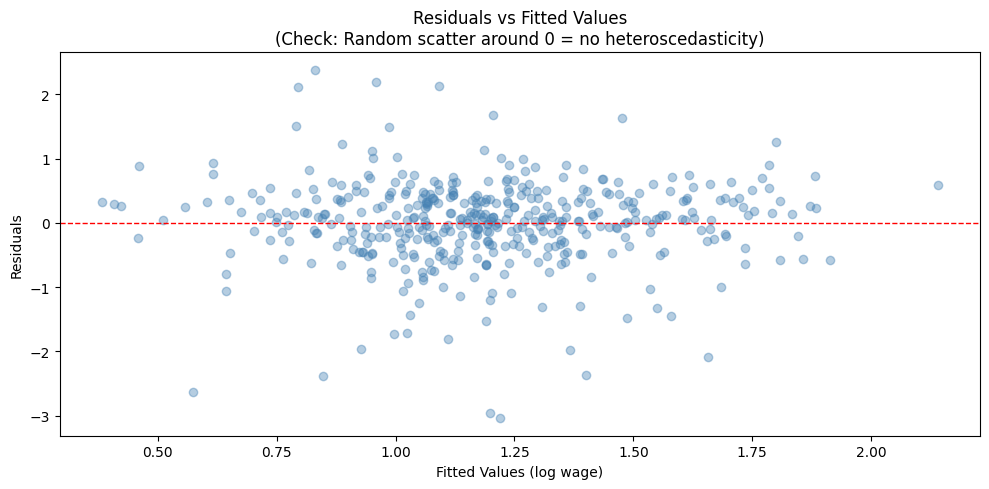

In [ ]:
fitted   = model_final.fittedvalues
residuals = model_final.resid

plt.figure(figsize=(10, 5))
plt.scatter(fitted, residuals, alpha=0.4, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals vs Fitted Values\n(Check: Random scatter around 0 = no heteroscedasticity)")
plt.xlabel("Fitted Values (log wage)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

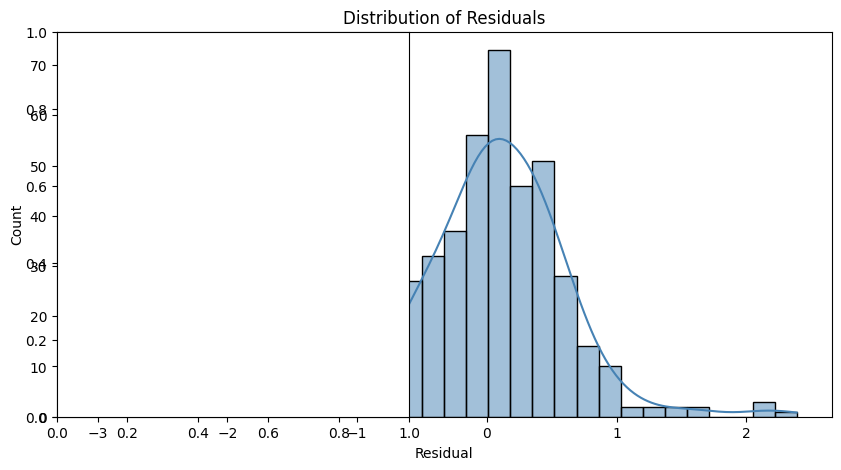

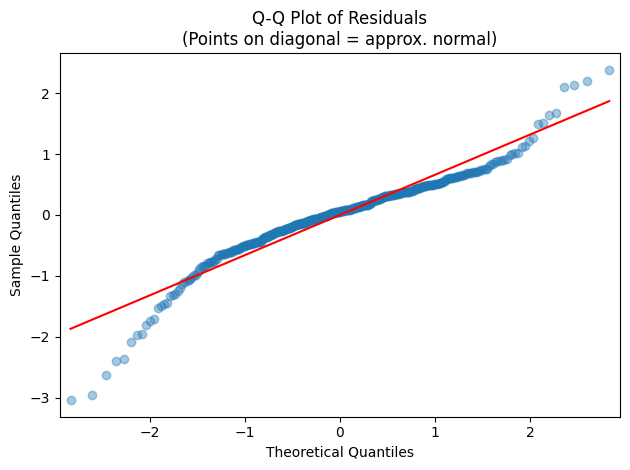

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1,1,1)
sns.histplot(residuals, kde=True, color='steelblue')
plt.title("Distribution of Residuals")
plt.xlabel("Residual")

plt.subplot(1,2,1)
sm.qqplot(residuals, line='s', alpha=0.4)
plt.title("Q-Q Plot of Residuals\n(Points on diagonal = approx. normal)")

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model_final.model.exog)
print("BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY")
print(f"LM Statistic:  {bp_test[0]:.2f}")
print(f"p-value:       {bp_test[1]:.2f}")
if bp_test[1] < 0.05:
    print("=> If p < 0.05: heteroscedasticity present (HC1 robust SE justified)")
else:
  print("=> If p > 0.05: homoscedastic (OLS standard errors would be valid)")

BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY
LM Statistic:  21.82
p-value:       0.01
=> If p < 0.05: heteroscedasticity present (HC1 robust SE justified)
